In [16]:
import matplotlib.pyplot as plt

In [6]:
# STEP 1 — Load saved train/test splits (created in Notebook 1)
import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Users\Saniya\Desktop\Customer churn ML end to end\data")

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nChurn distribution (train):")
print(y_train.value_counts(normalize=True))


Train: (5625, 19) | Test: (1407, 19)

Churn distribution (train):
0    0.734222
1    0.265778
Name: Churn, dtype: float64


In [7]:
# STEP 3 — Preprocessing Pipeline (ColumnTransformer)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify feature types again (important)
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

# Define transformers
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    drop='if_binary'
)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocessing pipeline created successfully")

Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
✅ Preprocessing pipeline created successfully


In [8]:
# STEP 4 — Logistic Regression Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Build full pipeline: preprocessing + model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

AUC-ROC: 0.8359


In [9]:
# STEP 5 — XGBoost
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles class imbalance
        random_state=42,
        eval_metric='logloss'
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

      Stayed       0.90      0.73      0.81      1033
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407

AUC-ROC: 0.8327


In [10]:
# STEP 6 — Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

      Stayed       0.90      0.74      0.81      1033
     Churned       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.75      0.76      1407

AUC-ROC: 0.8336


In [11]:
# STEP 7 — Model Comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'Churn Recall': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
    ],
    'Churn Precision': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision']
    ]
}).round(4)

print(comparison.to_string(index=False))

              Model  AUC-ROC  Churn Recall  Churn Precision
Logistic Regression   0.8359        0.5749           0.6495
            XGBoost   0.8327        0.7861           0.5122
      Random Forest   0.8336        0.7647           0.5153


In [12]:
# STEP 8 — Save best models
import joblib
from pathlib import Path

MODEL_DIR = Path(r"C:\Users\Saniya\Desktop\Customer churn ML end to end\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save Logistic Regression (production model — best AUC, interpretable)
joblib.dump(lr_pipeline, MODEL_DIR / "lr_pipeline.joblib")

# Save XGBoost (for SHAP explainability later)
joblib.dump(xgb_pipeline, MODEL_DIR / "xgb_pipeline.joblib")

print("✅ Models saved to", MODEL_DIR)

✅ Models saved to C:\Users\Saniya\Desktop\Customer churn ML end to end\models


In [14]:
!pip install shap

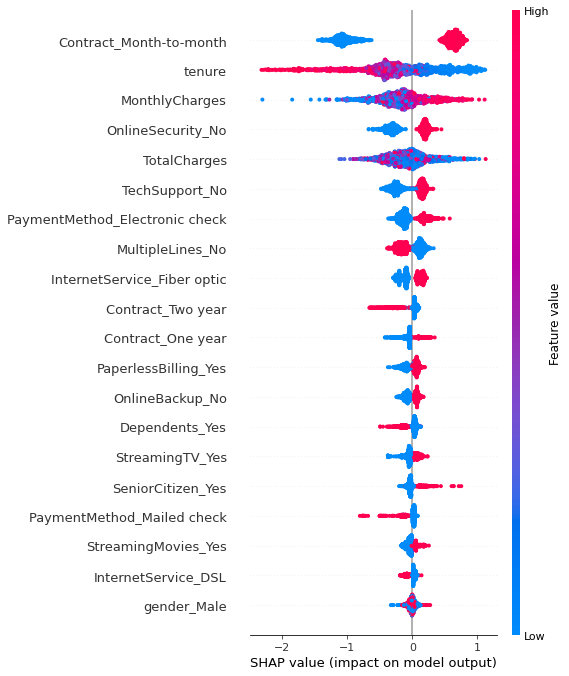

In [17]:
# STEP 9 — SHAP Explainability (XGBoost)
import shap

# Get the trained XGBoost model and preprocessor from the pipeline
xgb_model = xgb_pipeline.named_steps['model']
X_test_transformed = xgb_pipeline.named_steps['preprocessor'].transform(X_test)

# Get feature names
ohe = xgb_pipeline.named_steps['preprocessor'].named_transformers_['cat']
feature_names = numerical_features + ohe.get_feature_names_out(categorical_features).tolist()

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot — global feature importance
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(r"C:\Users\Saniya\Desktop\Customer churn ML end to end\reports\figures\shap_summary.png", dpi=150)
plt.show()